In [8]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [9]:
import os, random, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import timm
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

print("Библиотеки импортированы ✓")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
print(f"MPS  available:  {torch.backends.mps.is_available()}")


Библиотеки импортированы ✓
PyTorch version: 2.11.0
CUDA available:  False
MPS  available:  True


Исходное число строк: 1,451,784
После фильтра quality: 1,431,975
Найдено jpg файлов: 61,827
После mapping: 61,827
Число классов до очистки: 23
[WARNING] Удалено 2 классов с количеством образцов < 5

Итоговое число классов: 21
Итоговое число строк: 61,825


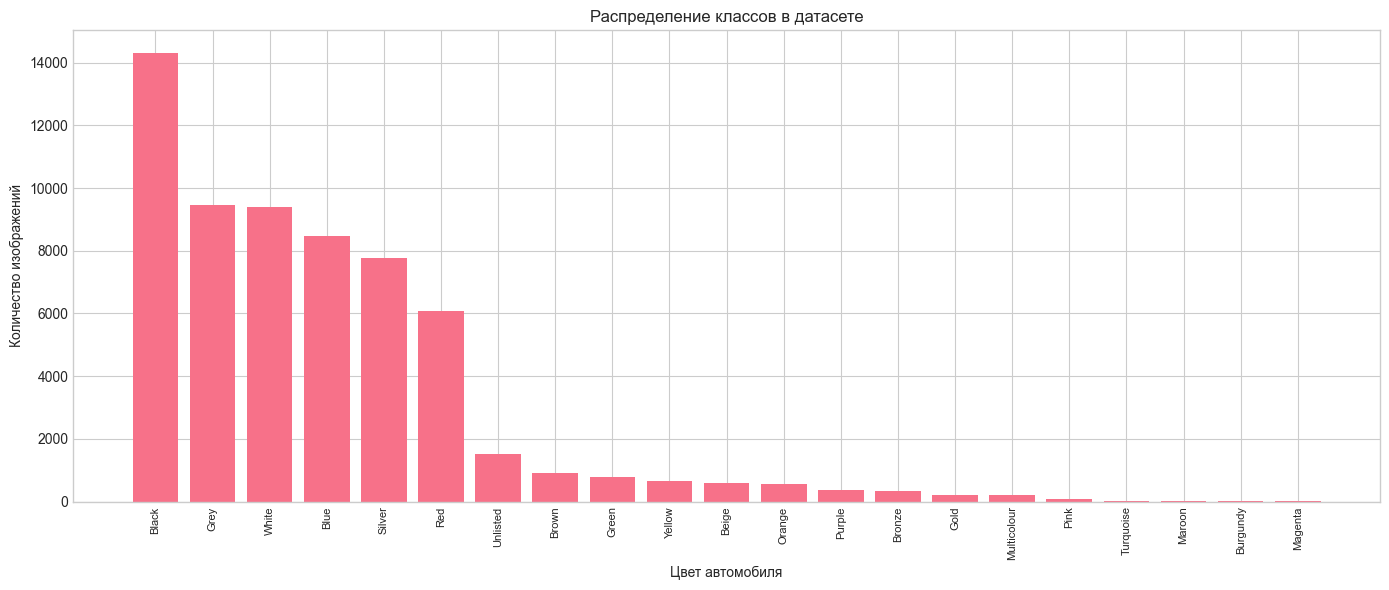

In [10]:
# Пути к данным
IMAGE_TABLE_PATH = Path('data/car_colors/1/Image_table.csv')
IMAGES_DIR = Path('data/car_colors/1/confirmed_fronts')

# Загрузка CSV
image_df = pd.read_csv(str(IMAGE_TABLE_PATH))
image_df.columns = [c.strip() for c in image_df.columns]
print(f'Исходное число строк: {len(image_df):,}')

# Парсинг имен файлов
def parse_image_name(name):
    parts = str(name).split('$$')
    if len(parts) >= 4:
        return {
            'color': parts[3].strip(),
            'quality': parts[4].strip() if len(parts) > 4 else '',
            'angle': parts[5].strip() if len(parts) > 5 else ''
        }
    return {'color': ''}

parsed = image_df['Image_name'].apply(parse_image_name)
image_df['parsed_color'] = parsed.apply(lambda x: x['color'])
image_df['parsed_quality'] = parsed.apply(lambda x: x['quality'])
image_df['parsed_angle'] = parsed.apply(lambda x: x['angle'])

# Фильтрация по качеству
USE_QUALITY_ONLY = True
if USE_QUALITY_ONLY and 'Quality_check' in image_df.columns:
    image_df = image_df[image_df['Quality_check'].fillna('').astype(str).str.strip().ne('N')].copy()
print(f'После фильтра quality: {len(image_df):,}')

# Маппинг путей к изображениям
all_image_paths = list(IMAGES_DIR.rglob('*.jpg'))
image_name_to_path = {path.name: path for path in all_image_paths}
print(f'Найдено jpg файлов: {len(all_image_paths):,}')

image_df['image_path'] = image_df['Image_name'].map(image_name_to_path)
image_df = image_df.dropna(subset=['image_path']).copy()
print(f'После mapping: {len(image_df):,}')

# Создание меток
color_to_idx = {color: idx for idx, color in enumerate(sorted(image_df['parsed_color'].unique()))}
idx_to_color = {idx: color for color, idx in color_to_idx.items()}
image_df['label'] = image_df['parsed_color'].map(color_to_idx)
num_classes_initial = len(color_to_idx)
print(f'Число классов до очистки: {num_classes_initial}')

# Очистка редких классов
class_counts = image_df['label'].value_counts()
MIN_SAMPLES_PER_CLASS = 5
valid_labels = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index

if len(valid_labels) < len(class_counts):
    removed_count = len(class_counts) - len(valid_labels)
    print(f'[WARNING] Удалено {removed_count} классов с количеством образцов < {MIN_SAMPLES_PER_CLASS}')

image_df = image_df[image_df['label'].isin(valid_labels)].reset_index(drop=True)

# Перекодирование меток в непрерывный диапазон [0, num_classes)
unique_colors = sorted(image_df['parsed_color'].unique())
color_to_idx = {color: idx for idx, color in enumerate(unique_colors)}
idx_to_color = {idx: color for color, idx in color_to_idx.items()}
image_df['label'] = image_df['parsed_color'].map(color_to_idx)
num_classes = len(color_to_idx)

print(f'\n{"="*50}')
print(f'Итоговое число классов: {num_classes}')
print(f'Итоговое число строк: {len(image_df):,}')
print(f'{"="*50}')

# Визуализация распределения классов
plt.figure(figsize=(14, 6))
class_distribution = image_df['parsed_color'].value_counts()
plt.bar(range(len(class_distribution)), class_distribution.values)
plt.xticks(range(len(class_distribution)), class_distribution.index, rotation=90, fontsize=8)
plt.xlabel('Цвет автомобиля')
plt.ylabel('Количество изображений')
plt.title('Распределение классов в датасете')
plt.tight_layout()
plt.show()

In [11]:
# Разделение на train/val
train_df, val_df = train_test_split(
    image_df,
    test_size=0.2,
    random_state=42,
    stratify=image_df['label']
)

print(f'Train size: {len(train_df):,} ({len(train_df)/len(image_df)*100:.1f}%)')
print(f'Val size: {len(val_df):,} ({len(val_df)/len(image_df)*100:.1f}%)')

# Трансформы
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    # ColorJitter исключён: изменение цвета разрушает целевой признак классификации
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class CarColorDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['image_path']
        label = row['label']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Создание DataLoader
train_dataset = CarColorDataset(train_df, transform=train_transforms)
val_dataset = CarColorDataset(val_df, transform=val_transforms)

# pin_memory работает только с CUDA; для MPS/CPU отключаем
_pin = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=_pin)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=_pin)

print(f"\nBatch size: 32")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train size: 49,460 (80.0%)
Val size: 12,365 (20.0%)

Batch size: 32
Train batches: 1546
Val batches: 387


In [12]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc='Validating', leave=False):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1, all_preds, all_labels

def train_model(model, model_name, train_loader, val_loader, num_classes, epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_f1 = 0
    best_model_state = None

    print(f"\n{'='*60}")
    print(f"Обучение модели: {model_name}")
    print(f"{'='*60}")

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        train_loss, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1, _, _ = validate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        print(f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_state = model.state_dict().copy()

    print(f"\nЛучший F1 Macro: {best_f1:.4f}")
    print(f"{'='*60}\n")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history, best_f1

def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history['train_f1'], label='Train F1', marker='o')
    axes[1].plot(history['val_f1'], label='Val F1', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 Macro')
    axes[1].set_title(f'{model_name} - F1 Macro')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(all_labels, all_preds, model_name, class_names=None):
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.tight_layout()
    plt.show()

Device: mps


In [13]:
print("\n" + "="*60)
print("МОДЕЛЬ 1: ResNet50 (Pretrained на ImageNet)")
print("="*60)

# 1. Загрузка модели
model1 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# 2. Заморозка всех слоев
for param in model1.parameters():
    param.requires_grad = False

# 3. Замена классификатора
num_features = model1.fc.in_features
model1.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, num_classes)
)

# 4. Разморозка последних слоев для fine-tuning
for param in model1.layer4.parameters():
    param.requires_grad = True
# Также размораживаем новый классификатор (он и так требует градиенты, но для ясности)
for param in model1.fc.parameters():
    param.requires_grad = True

# 5. Перенос на устройство ДО создания оптимизатора
model1 = model1.to(device)

# 6. Проверка: сколько параметров обучается
trainable_params = sum(p.numel() for p in model1.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model1.parameters())
print(f"Обучаемых параметров: {trainable_params:,} / {total_params:,} ({trainable_params/total_params*100:.1f}%)")

# 7. Если параметров слишком мало — разморозим ещё слой
if trainable_params < 1_000_000:
    print("[INFO] Мало обучаемых параметров, размораживаем layer3...")
    for param in model1.layer3.parameters():
        param.requires_grad = True

# 8. Создание оптимизатора (после настройки requires_grad!)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model1.parameters()),  # Только обучаемые параметры
    lr=0.001,
    weight_decay=0.01
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# 9. Уменьшенный batch size для экономии памяти
# На MPS/CPU памяти достаточно для batch 32; при OOM уменьшить до 16
BATCH_SIZE = 32
_pin = torch.cuda.is_available()
train_loader_finetune = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=_pin)
val_loader_finetune = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=_pin)

print(f"Batch size: {BATCH_SIZE}")
print(f"Device: {device}")

# 10. Простая функция обучения с понятным выводом
def train_simple(model, train_ld, val_ld, epochs, lr):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_f1 = 0
    best_model_state = None

    for epoch in range(epochs):
        # === TRAIN ===
        model.train()
        train_loss, correct, total = 0, 0, 0
        all_preds, all_labels = [], []

        for batch_idx, (imgs, lbls) in enumerate(train_ld):
            imgs, lbls = imgs.to(device), lbls.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == lbls).sum().item()
            total += lbls.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

            # Вывод прогресса каждые 50 батчей
            if (batch_idx + 1) % 50 == 0:
                print(f"  Batch {batch_idx+1}/{len(train_ld)} | Loss: {loss.item():.4f}")

        train_acc = correct / total
        train_f1 = f1_score(all_labels, all_preds, average='macro')
        avg_train_loss = train_loss / len(train_ld)
        scheduler.step()

        # === VALIDATE ===
        model.eval()
        val_loss, correct, total = 0, 0, 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for imgs, lbls in val_ld:
                imgs, lbls = imgs.to(device), lbls.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, lbls)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                correct += (preds == lbls).sum().item()
                total += lbls.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(lbls.cpu().numpy())

        val_acc = correct / total
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        avg_val_loss = val_loss / len(val_ld)

        # Сохранение истории
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        # Вывод результатов эпохи
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train → Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"  Val   → Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  ★ Новый лучший результат: {best_f1:.4f}")

    if best_model_state is not None:
        model.load_state_dict({k: v.to(next(model.parameters()).device) for k, v in best_model_state.items()})

    return model, history, best_f1

# 11. Запуск обучения
print("\n[Начало обучения...]")
model1, history1, best_f1_1 = train_simple(
    model1,
    train_loader_finetune,
    val_loader_finetune,
    epochs=5,  # Начнем с 5 эпох для теста
    lr=0.001
)

print(f"\n✓ Обучение завершено! Лучший F1 Macro: {best_f1_1:.4f}")

# Финальная валидация для получения предсказаний (нужны в Cell 7 и 8)
val_loss1, val_f1_1, preds1, labels1 = validate(model1, val_loader_finetune, nn.CrossEntropyLoss().to(device), device)
print(f"Финальный F1 Macro (ResNet50): {val_f1_1:.4f}")
plot_history(history1, "ResNet50 (ImageNet)")


МОДЕЛЬ 1: ResNet50 (Pretrained на ImageNet)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/ivanivanov/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>

In [ ]:
print("\n" + "="*60)
print("МОДЕЛЬ 2: ConvNeXt-Tiny (Pretrained на ImageNet-22K)")
print("="*60)
print("""
Архитектура ConvNeXt (Liu et al., 2022):
  - Чисто сверточная сеть, вдохновлённая дизайном Vision Transformer
  - Depthwise conv 7×7 вместо 3×3 — большее рецептивное поле без роста параметров
  - Inverted bottleneck: расширение каналов 4× внутри блока (как в ViT FFN)
  - GELU вместо ReLU, LayerNorm вместо BatchNorm
  - Меньше нормировочных слоёв → стабильнее с большими batch

Предобучение: Facebook ImageNet-22K
  - ~14 млн изображений, 21 841 класс (vs 1 281 167 / 1 000 в стандартном ImageNet-1K)
  - Намного более разнообразный словарь признаков → лучше переносится на нашу задачу
""")

model2 = timm.create_model('convnext_tiny.fb_in22k', pretrained=True, num_classes=num_classes)

trainable2 = sum(p.numel() for p in model2.parameters() if p.requires_grad)
total2 = sum(p.numel() for p in model2.parameters())
print(f"Параметров: {trainable2:,} / {total2:,} ({trainable2/total2*100:.1f}% обучаемых)")

model2, history2, best_f1_2 = train_model(
    model2,
    "ConvNeXt-Tiny (ImageNet-22K)",
    train_loader,
    val_loader,
    num_classes,
    epochs=10,
    lr=0.0005
)

val_loss2, val_f1_2, preds2, labels2 = validate(model2, val_loader, nn.CrossEntropyLoss(), device)
print(f"Финальный F1 Macro (ConvNeXt-Tiny): {val_f1_2:.4f}")

plot_history(history2, "ConvNeXt-Tiny (ImageNet-22K)")


In [ ]:
print("\n" + "="*60)
print("MODEL 3: Custom CNN (From Scratch, rewritten)")
print("="*60)

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, stride=s, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, downsample=False, drop=0.10):
        super().__init__()
        stride = 2 if downsample else 1
        self.conv1 = ConvBNAct(in_ch, out_ch, k=3, s=stride, p=1)
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.act = nn.SiLU(inplace=True)
        self.drop = nn.Dropout2d(drop)

        if downsample or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.drop(x)
        x = x + identity
        return self.act(x)


class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBNAct(3, 32, k=3, s=2, p=1),  # 224 -> 112
            ConvBNAct(32, 32, k=3, s=1, p=1),
        )

        self.stage1 = nn.Sequential(
            ResidualBlock(32, 64, downsample=True, drop=0.05),  # 112 -> 56
            ResidualBlock(64, 64, downsample=False, drop=0.05),
        )
        self.stage2 = nn.Sequential(
            ResidualBlock(64, 128, downsample=True, drop=0.10),  # 56 -> 28
            ResidualBlock(128, 128, downsample=False, drop=0.10),
        )
        self.stage3 = nn.Sequential(
            ResidualBlock(128, 256, downsample=True, drop=0.15),  # 28 -> 14
            ResidualBlock(256, 256, downsample=False, drop=0.15),
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(256),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                if hasattr(m, 'weight') and m.weight is not None:
                    nn.init.ones_(m.weight)
                if hasattr(m, 'bias') and m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.head(x)
        return x


def class_weights_from_loader(loader, num_classes, device):
    counts = torch.zeros(num_classes, dtype=torch.float64)
    for _, y in loader:
        counts += torch.bincount(y, minlength=num_classes).double()
    counts = counts.clamp_min(1.0)
    weights = counts.sum() / (counts * num_classes)
    weights = weights / weights.mean()
    return weights.float().to(device)


def train_custom_scratch(model, train_loader, val_loader, epochs=20):
    model = model.to(device)

    class_w = class_weights_from_loader(train_loader, num_classes, device)
    criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=0.05)

    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=1e-3,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.2,
        div_factor=10.0,
        final_div_factor=100.0,
    )

    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_f1 = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        all_preds, all_labels = [], []

        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
                outputs = model(imgs)
                loss = criterion(outputs, lbls)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(lbls.detach().cpu().numpy())

        train_loss = running_loss / max(1, len(train_loader))
        train_f1 = f1_score(all_labels, all_preds, average='macro')

        val_loss, val_f1, _, _ = validate(model, val_loader, nn.CrossEntropyLoss().to(device), device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch+1:02d}/{epochs} | train_loss={train_loss:.4f} train_f1={train_f1:.4f} | val_loss={val_loss:.4f} val_f1={val_f1:.4f}")

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    return model, history, best_f1


model3 = CustomCNN(num_classes)
total_params = sum(p.numel() for p in model3.parameters())
trainable_params = sum(p.numel() for p in model3.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

model3, history3, best_f1_3 = train_custom_scratch(
    model3,
    train_loader,
    val_loader,
    epochs=25
)

val_loss3, val_f1_3, preds3, labels3 = validate(model3, val_loader, nn.CrossEntropyLoss().to(device), device)
print(f"Final F1 Macro (CustomCNN): {val_f1_3:.4f}")

plot_history(history3, "CustomCNN (From Scratch, rewritten)")


In [ ]:
print("\n" + "="*60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ ВСЕХ МОДЕЛЕЙ")
print("="*60)

# Создание таблицы результатов
results = pd.DataFrame({
    'Модель': ['ResNet50 (ImageNet)', 'ConvNeXt-Tiny (ImageNet-22K)', 'CustomCNN (From Scratch)'],
    'F1 Macro': [val_f1_1, val_f1_2, val_f1_3],
    'Лучший F1': [best_f1_1, best_f1_2, best_f1_3],
    'Эпохи': [5, 10, 15],
    'Предобучение': ['ImageNet', 'ImageNet21K', 'Нет']
})

print(results.to_string(index=False))

# Визуализация сравнения
plt.figure(figsize=(12, 6))
bars = plt.bar(results['Модель'], results['F1 Macro'], color=['#3498db', '#2ecc71', '#e74c3c'])
plt.xlabel('Модель')
plt.ylabel('F1 Macro Score')
plt.title('Сравнение качества классификации моделей')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)

# Добавление значений на столбцы
for bar, val in zip(bars, results['F1 Macro']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Сравнение кривых обучения
plt.figure(figsize=(14, 6))
plt.plot(history1['val_f1'], label='ResNet50 (ImageNet)', marker='o', linewidth=2)
plt.plot(history2['val_f1'], label='ConvNeXt-Tiny (ImageNet-22K)', marker='s', linewidth=2)
plt.plot(history3['val_f1'], label='CustomCNN (From Scratch)', marker='^', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation F1 Macro')
plt.title('Сравнение кривых обучения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ КАЧЕСТВА")
print("="*60)

# Classification Report для лучшей модели
best_model_idx = results['F1 Macro'].idxmax()
best_model_name = results.iloc[best_model_idx]['Модель']
best_f1 = results.iloc[best_model_idx]['F1 Macro']

print(f"\nЛучшая модель: {best_model_name}")
print(f"F1 Macro: {best_f1:.4f}")

# Определение какой модель лучше
if best_model_idx == 0:
    best_preds, best_labels = preds1, labels1
elif best_model_idx == 1:
    best_preds, best_labels = preds2, labels2
else:
    best_preds, best_labels = preds3, labels3

print("\n" + "-"*60)
print("Classification Report (лучшая модель):")
print("-"*60)
print(classification_report(best_labels, best_preds,
                            target_names=[idx_to_color[i] for i in range(num_classes)],
                            digits=4))

# Матрица ошибок
plot_confusion_matrix(best_labels, best_preds, best_model_name)

# Выводы
print("\n" + "="*60)
print("ВЫВОДЫ")
print("="*60)

print(f"""
1. КАЧЕСТВО КЛАССИФИКАЦИИ:
   - Лучший результат: {best_f1:.4f} ({best_model_name})
   - {'Отличное' if best_f1 > 0.9 else 'Хорошее' if best_f1 > 0.7 else 'Удовлетворительное' if best_f1 > 0.5 else 'Плохое'} качество

2. TRANSFER LEARNING vs ОБУЧЕНИЕ С НУЛЯ:
   - ResNet50 (ImageNet): F1 = {val_f1_1:.4f}
   - ConvNeXt-Tiny (IN-22K): F1 = {val_f1_2:.4f}
   - CustomCNN (From Scratch): F1 = {val_f1_3:.4f}
   - Transfer learning показывает преимущество на {max(val_f1_1, val_f1_2) - val_f1_3:.4f} F1

3. ПРЕИМУЩЕСТВА TRANSFER LEARNING:
   - Быстрее сходится (меньше эпох)
   - Лучше обобщает на малых данных
   - Стабильнее обучение

4. ПРОБЛЕМЫ ОБУЧЕНИЯ С НУЛЯ:
   - Требует больше данных и эпох
   - Риск переобучения выше
   - Нужна тщательная регуляризация

5. ЗНАЧЕНИЕ F1_MACRO:
   - Среднее арифметическое F1 по всем классам: F1_macro = (1/N) * Σ F1_i
   - F1_i = 2 * Precision_i * Recall_i / (Precision_i + Recall_i)
   - Отличие от accuracy: каждый класс вносит равный вклад независимо от размера
   - Отличие от F1_micro: не занижает редкие классы за счёт частых
   - Значение {best_f1:.4f} — среднее F1 по всем цветам; низкий F1 у редких цветов
     (например, бежевый, розовый) тянет метрику вниз даже при высокой accuracy
""")

# Сохранение результатов
results.to_csv('lab4_results.csv', index=False)
print("\nРезультаты сохранены в 'lab4_results.csv' ✓")